In [1]:
#!pip install -r requirements.txt

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from datetime import timedelta

from scipy import stats
from sklearn import preprocessing
from sklearn.model_selection import (train_test_split, cross_validate,
                                     StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score,
                             average_precision_score, silhouette_score,
                             adjusted_rand_score, RocCurveDisplay,
                             PrecisionRecallDisplay, classification_report)

sns.set_theme(style="whitegrid", palette="muted")


### Data Loading
Download the Portuguese bank-marketing dataset (45,211 clients, 17 columns) and load it as a DataFrame.


In [3]:
def load_data(test=False):
    path = kagglehub.dataset_download("prakharrathi25/banking-dataset-marketing-targets")
    df = pd.read_csv(f"{path}/train.csv", sep=';')
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns.")
    return df

In [4]:
train_df = load_data()

Dataset loaded: 45211 rows, 17 columns.


### Data Inspection
Review data types, `unknown` placeholders and IQR outliers before any cleaning.


In [5]:
def get_dataset_summary(df):
    """
    Performs basic dataset exploration: types, nulls, and 'unknown' values.
    Reflects the 'inspect before training' goal from Lab 1.
    """
    print(f"--- Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns ---")
    
    # 1. Inspect Data Types (Important for determining encoding strategies)
    print("\n--- Feature Data Types ---")
    print(df.dtypes)
    
    # 2. Check for standard NaNs (Though this dataset typically uses 'unknown')
    print("\n--- Standard Missing Values (NaNs) ---")
    print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().any() else "No standard NaNs found.")
    
    # 3. Check for 'unknown' strings (The dataset's specific way of marking missing data)
    print("\n--- 'Unknown' Value Counts per Column ---")
    found_unknown = False
    for col in df.columns:
        # Check if 'unknown' exists in the column
        unknown_count = (df[col] == 'unknown').sum()
        if unknown_count > 0:
            percentage = (unknown_count / len(df)) * 100
            print(f"{col:12}: {unknown_count:>5} values ({percentage:.2f}%)")
            found_unknown = True
            
    if not found_unknown:
        print("No 'unknown' values detected.")

def analyze_outliers(df):
    """
    Identifies outliers using the IQR method from Lab 1.
    Calculates the percentage of data points that fall outside the bounds.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    print("--- Outlier Analysis (IQR Method) ---")
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        percentage = (len(outliers) / len(df)) * 100
        
        print(f"{col:10}: {len(outliers):>5} outliers ({percentage:.2f}%)")

In [6]:
get_dataset_summary(train_df)
analyze_outliers(train_df)

--- Dataset Dimensions: 45211 rows, 17 columns ---

--- Feature Data Types ---
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

--- Standard Missing Values (NaNs) ---
No standard NaNs found.

--- 'Unknown' Value Counts per Column ---
job         :   288 values (0.64%)
education   :  1857 values (4.11%)
contact     : 13020 values (28.80%)
poutcome    : 36959 values (81.75%)
--- Outlier Analysis (IQR Method) ---
age       :   487 outliers (1.08%)
balance   :  4729 outliers (10.46%)
day       :     0 outliers (0.00%)
duration  :  3235 outliers (7.16%)
campaign  :  3064 outliers (6.78%)
pdays     :  8257 outliers (18.26%)
previous  :  8257 outliers (18.26%)


### Exploratory Data Analysis
Distributions, class imbalance and feature–target relationships that motivate the preprocessing choices.


In [7]:
def plot_target_distribution(df):
    """
    Visualizes class imbalance using a Pie Chart.
    As seen in Lab 5, identifying imbalance is critical for choosing metrics.
    """
    plt.figure(figsize=(8, 6))
    counts = df['y'].value_counts()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', 
            startangle=140, colors=['#ff9999','#66b3ff'], explode=(0.1, 0))
    plt.title('Target Variable: Subscription Success Rate')
    plt.show()

def plot_numeric_distributions(df):
    """
    Expanded numeric check. Showing 4 is okay, but adding 'pdays' and 'previous' 
    helps identify patterns in contact frequency.
    """
    numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
    # Creating a 3x2 grid to accommodate more features
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(numeric_cols):
        sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color='teal')
        axes[i].set_title(f'Distribution of {col.capitalize()}')
    
    plt.tight_layout()
    plt.show()

def plot_categorical_proportions(df, cat_col):
    """
    FIXED: Removed the '0 Axes' error by passing the ax object correctly.
    This helps identify which segments to target.
    """
    # Create the figure and axis first
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Calculate proportions
    prop_df = pd.crosstab(df[cat_col], df['y'], normalize='index') * 100
    
    # Plot directly onto the axis 'ax'
    prop_df.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=ax)
    
    ax.set_title(f'Subscription Success Percentage by {cat_col.capitalize()}')
    ax.set_ylabel('Percentage %')
    plt.xticks(rotation=45)
    plt.legend(title='Subscribed?', labels=['No', 'Yes'], loc='upper right')
    plt.show()

def plot_correlation_heatmap(df):
    """
    Visualizes relationships between numerical features.
    Helps identify multicollinearity before modeling.
    """
    plt.figure(figsize=(10, 8))
    # Select only numeric columns
    numeric_df = df.select_dtypes(include=[np.number])
    corr = numeric_df.corr()
    
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()

def plot_duration_impact(df):
    """
    Uses a boxplot to see the distribution of call duration for each outcome.
    Helps identify if there is a 'minimum time' needed for success.
    """
    plt.figure(figsize=(10, 6))
    # Fix: assign x to hue and set legend=False to suppress the warning
    sns.boxplot(x='y', y='duration', data=df, hue='y', palette='Set2', legend=False)
    plt.yscale('log') 
    plt.title('Impact of Call Duration on Subscription (Log Scale)')
    plt.ylabel('Duration (seconds - Log Scale)')
    plt.xlabel('Subscribed?')
    plt.show()

def plot_debt_vs_conversion(df):
    """
    Bivariate analysis of housing/personal loans vs. target.
    Does existing debt prevent clients from investing in deposits?
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Housing Loan vs Target
    prop_housing = pd.crosstab(df['housing'], df['y'], normalize='index') * 100
    prop_housing.plot(kind='bar', stacked=True, ax=ax1, color=['#e74c3c', '#2ecc71'])
    ax1.set_title('Subscription Rate: Housing Loan Status')
    
    # Personal Loan vs Target
    prop_loan = pd.crosstab(df['loan'], df['y'], normalize='index') * 100
    prop_loan.plot(kind='bar', stacked=True, ax=ax2, color=['#e74c3c', '#2ecc71'])
    ax2.set_title('Subscription Rate: Personal Loan Status')
    
    plt.show()

def plot_campaign_efficiency(df):
    """
    Visualizes success rate based on the number of contacts in this campaign.
    Identifies the 'sweet spot' for resource allocation.
    """
    plt.figure(figsize=(12, 6))
    # Group by number of contacts and calculate mean 'yes' (1) vs 'no' (0)
    # First, convert 'y' to numeric for calculation
    temp_df = df.copy()
    temp_df['y_numeric'] = temp_df['y'].map({'yes': 1, 'no': 0})
    
    efficiency = temp_df.groupby('campaign')['y_numeric'].mean() * 100
    efficiency.head(10).plot(kind='line', marker='o', color='purple')
    
    plt.title('Conversion Rate % by Number of Contacts (Campaign)')
    plt.xlabel('Number of Contacts during this Campaign')
    plt.ylabel('Success Rate (%)')
    plt.grid(True)
    plt.show()


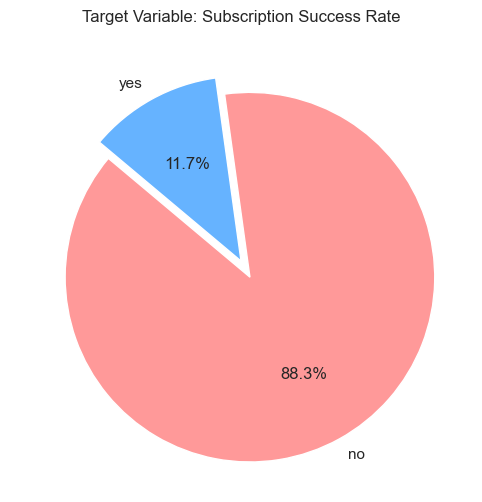

In [8]:
# Class Imbalance (Pie Chart)
plot_target_distribution(train_df)

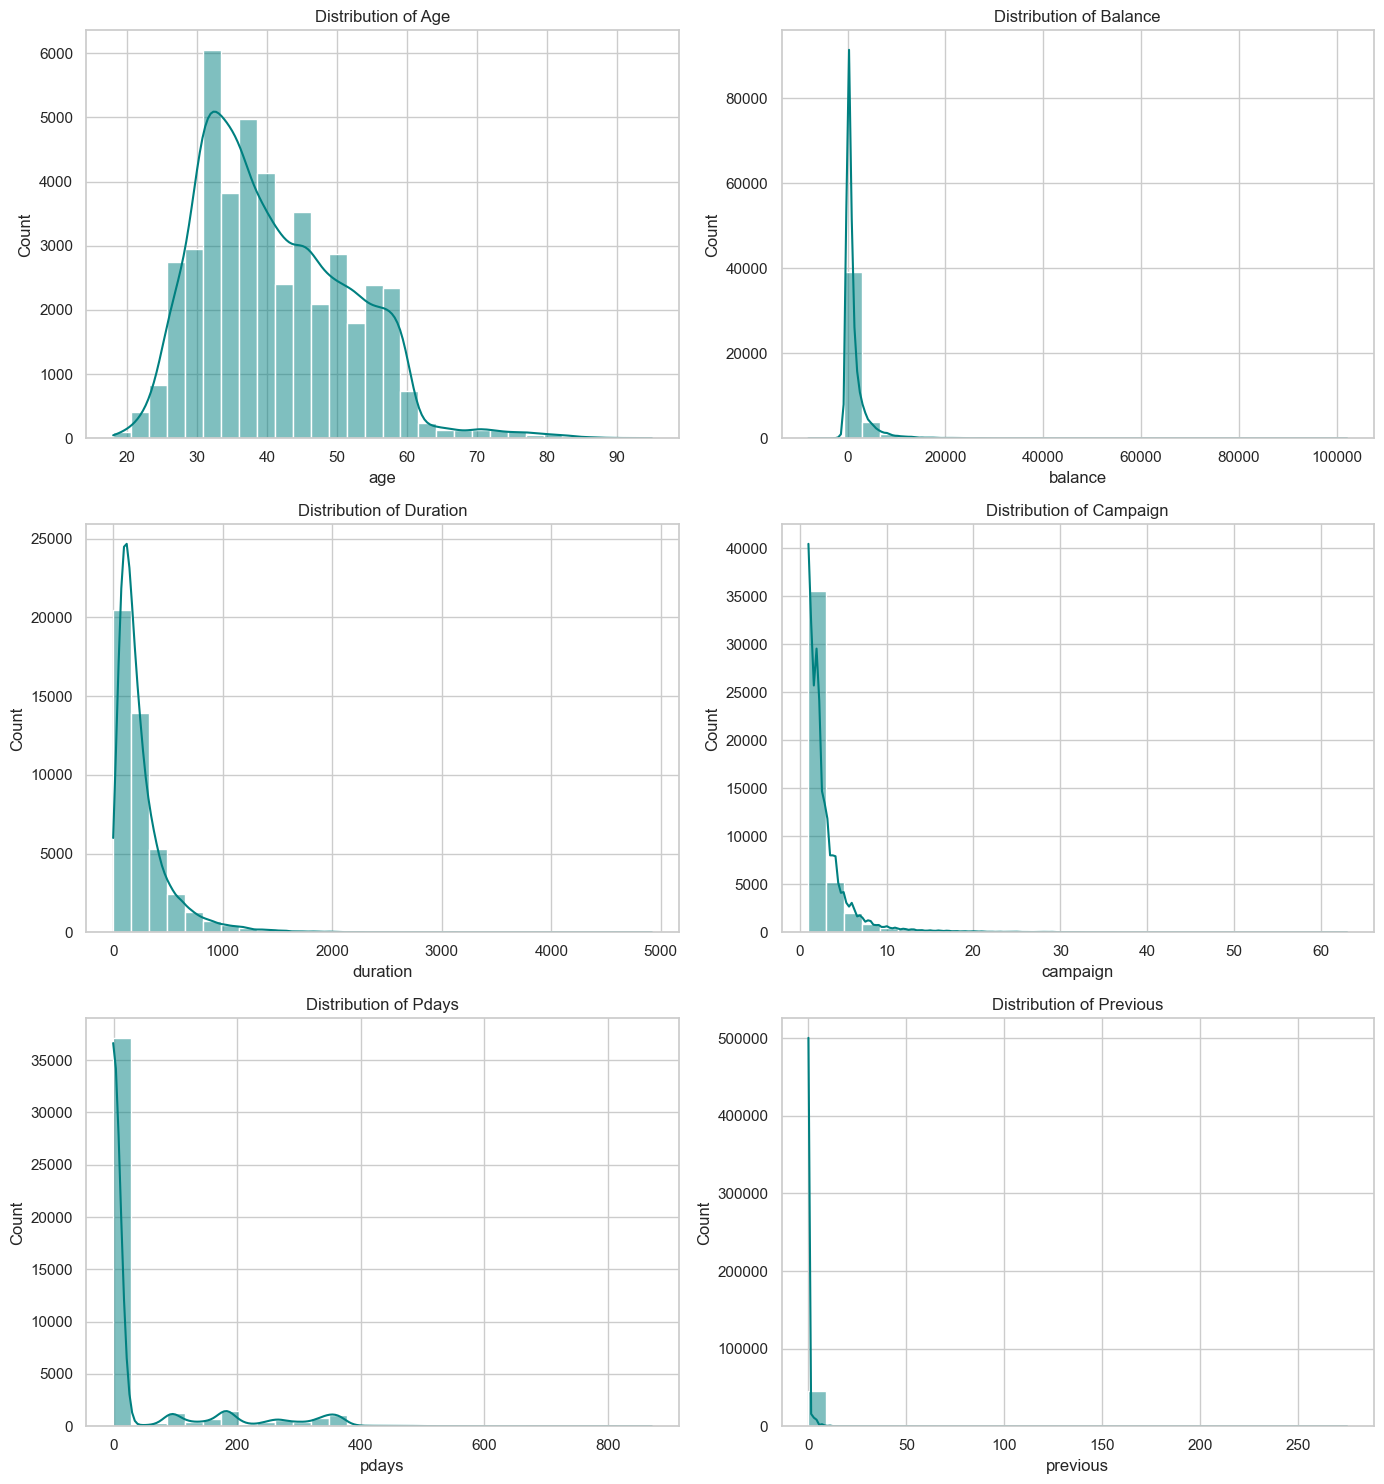

In [9]:
# Numeric Distributions 
plot_numeric_distributions(train_df)

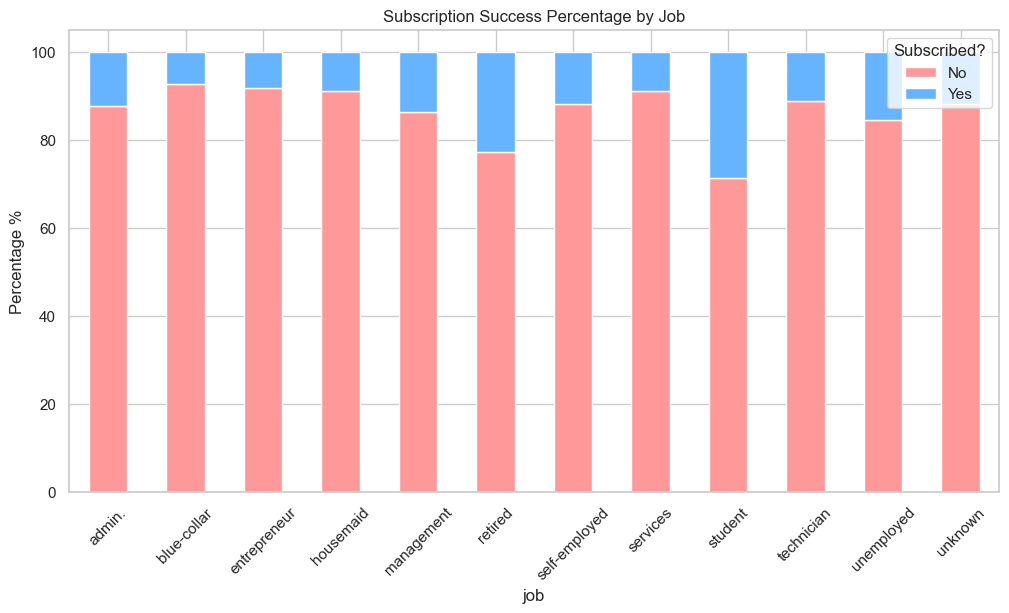

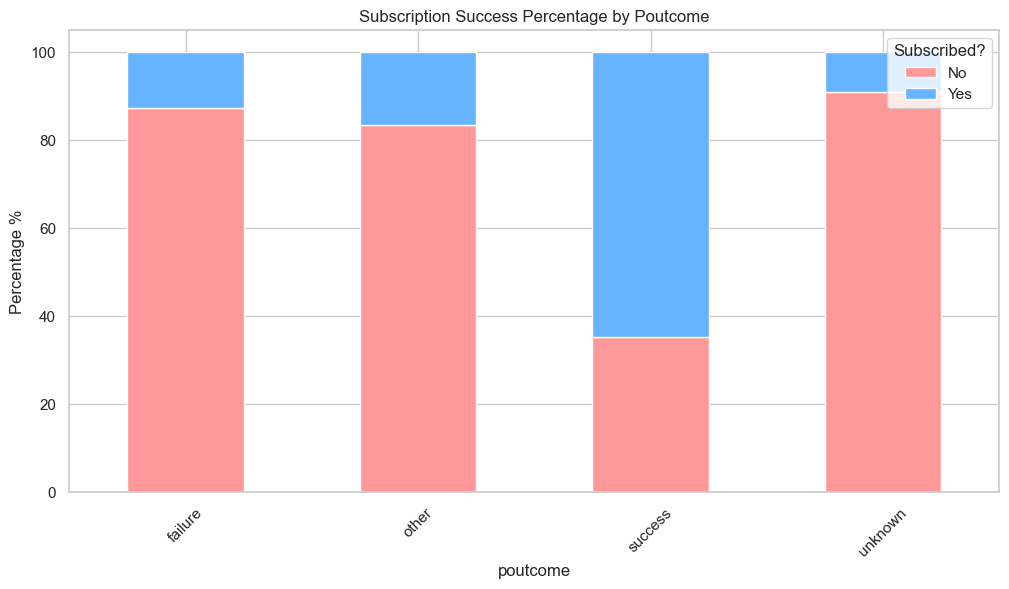

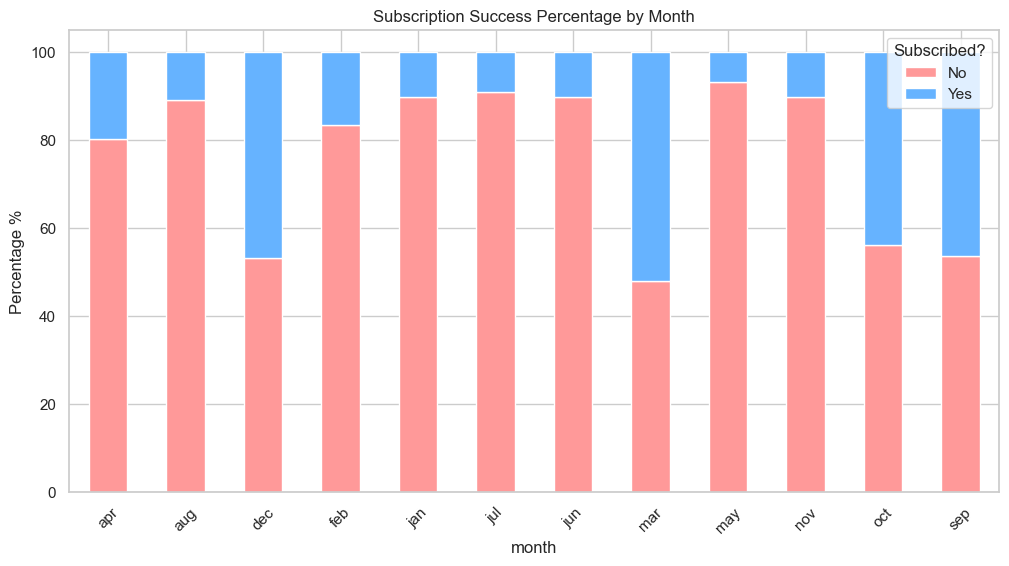

In [10]:
# 3. Categorical Analysis 
plot_categorical_proportions(train_df, 'job')
plot_categorical_proportions(train_df, 'poutcome') 
plot_categorical_proportions(train_df, 'month') 

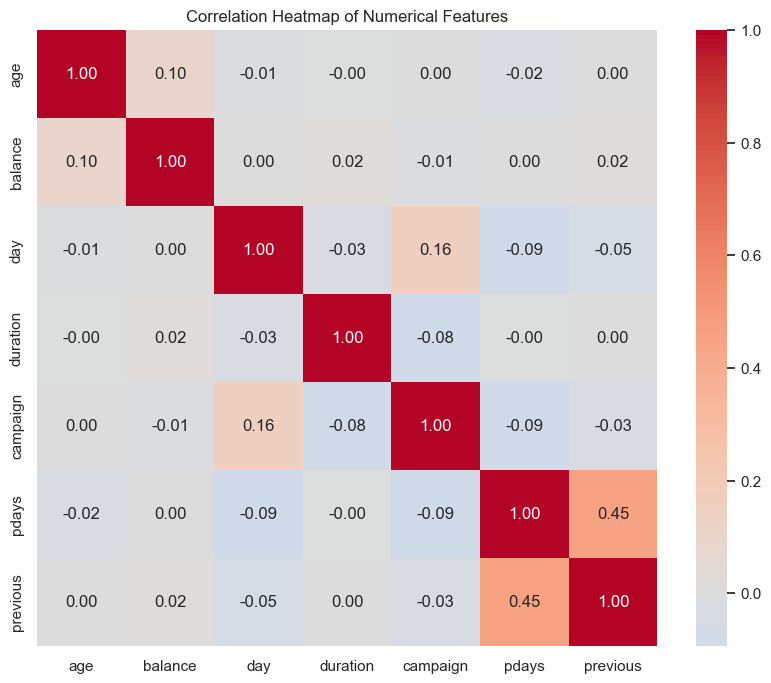

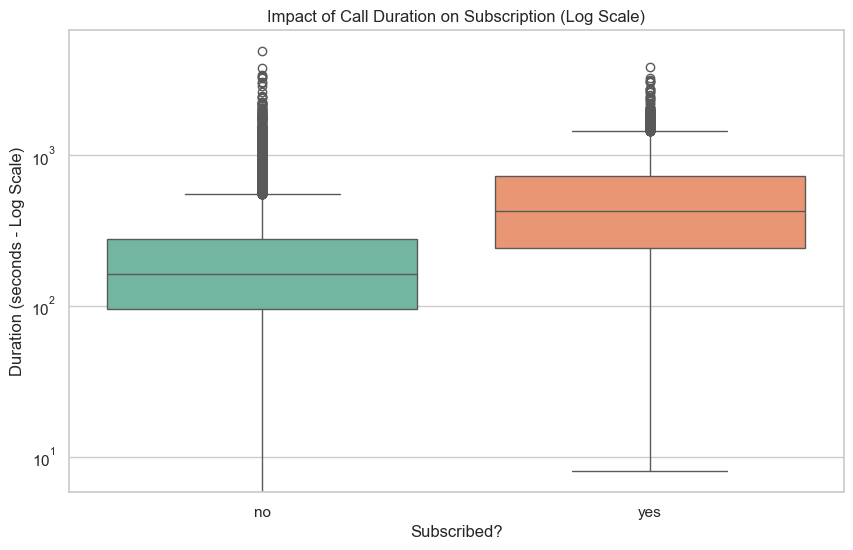

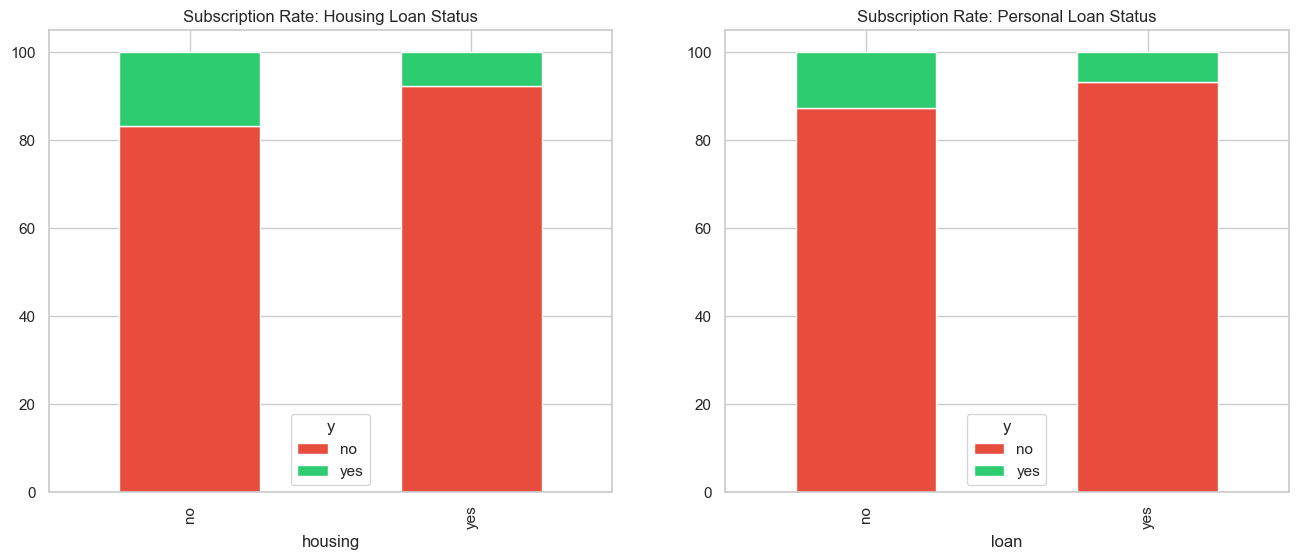

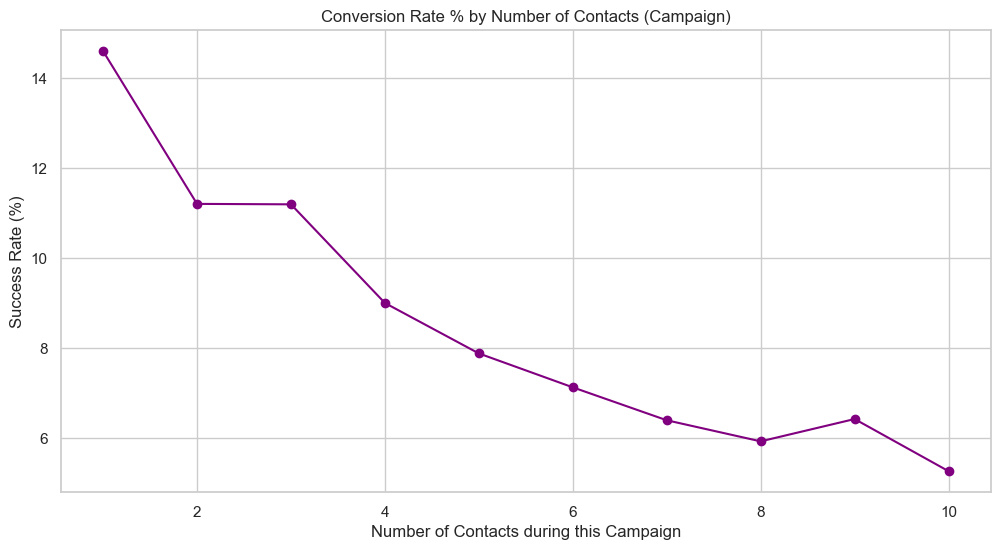

In [11]:
# 4. Advanced Insights 
plot_correlation_heatmap(train_df)
plot_duration_impact(train_df)
plot_debt_vs_conversion(train_df)
plot_campaign_efficiency(train_df)

### Preprocessing
Impute `unknown`s, clip outliers, log-transform skewed features, encode categoricals, then scale (fit on train only).


In [12]:
# For both education and month, it matters how close they are, therefore ordinal encoding is appropriate. 
EDUCATION_ORDER = {
    'primary':   1,
    'secondary': 2,
    'tertiary':  3,
}
 
MONTH_ORDER = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12,
}

# Yes or no is binary, so we can map to 1/0. 
BINARY_COLS = ['default', 'housing', 'loan']
 
# Columns with no natural order → one-hot encoded
OHE_COLS = ['job', 'marital', 'contact', 'poutcome']
 
# Right-skewed numerics (based on visualization of their distributions) that benefit from log compression.
# balance can be negative so it is handled separately
LOG_COLS = ['duration', 'campaign', 'pdays', 'previous']

In [13]:
# Preprocessing structure through pipeline

def preprocess_data(df, log_transform=True):
    df = df.copy()

    # Missing Removal
    df.replace('unknown', np.nan, inplace=True)
    for col in df.columns:
        if df[col].isna().any():
            df[col] = df[col].fillna(df[col].mode()[0])
    assert df.isna().sum().sum() == 0, "Unexpected NaNs remain after imputation"

    # Outlier Removal
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != 'y']
    Q1 = df[numeric_cols].quantile(0.25)
    Q3 = df[numeric_cols].quantile(0.75)
    IQR = Q3 - Q1
    for col in numeric_cols:
        lower = Q1[col] - 1.5 * IQR[col]
        upper = Q3[col] + 1.5 * IQR[col]
        df[col] = np.clip(df[col], lower, upper)

    # Log transformation for skewed features
    df['pdays'] = df['pdays'].replace(-1, 0)
    if log_transform:
        for col in LOG_COLS:
            df[col] = np.log1p(df[col])
        shift = df['balance'].min()
        if shift < 0:
            df['balance'] = df['balance'] - shift
        df['balance'] = np.log1p(df['balance'])

    # Categorical Encoding
    if 'education' in df.columns:
        df['education'] = df['education'].map(EDUCATION_ORDER)

    month_num = df['month'].map(MONTH_ORDER)
    df['month_sin'] = np.sin(2 * np.pi * month_num / 12)
    df['month_cos'] = np.cos(2 * np.pi * month_num / 12)
    df.drop(columns=['month'], inplace=True)

    for col in BINARY_COLS:
        df[col] = df[col].map({'yes': 1, 'no': 0})

    df = pd.get_dummies(df, columns=OHE_COLS, drop_first=True, dtype=int)
    df['y'] = df['y'].map({'yes': 1, 'no': 0})

    # Feature Engineering
    df['contact_ratio'] = df['previous'] / (df['campaign'] + 1)

    return df


In [14]:
def split_and_scale(df, target='y', test_size=0.2, random_state=42, scale=True):
    X = df.drop(columns=[target])
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    if scale:
        scaler = preprocessing.StandardScaler()
        X_train = pd.DataFrame(
            scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
        )
        X_test = pd.DataFrame(
            scaler.transform(X_test), columns=X_test.columns, index=X_test.index
        )

    print(f"Train: {X_train.shape}, Test: {X_test.shape}")
    print(f"Class balance (train) — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")

    return X_train, X_test, y_train, y_test


## Phase I — Unsupervised Structural Analysis

PCA to see how many dimensions carry the variance, then K-Means + GMM to check whether
customers form natural groups that line up with the target `y`. Fit on the scaled training split only.


In [15]:
def pca_analysis(X_train, y_train, var_threshold=0.90):
    """PCA explained variance + 2D projection coloured by the target."""
    pca = PCA().fit(X_train)
    cum = np.cumsum(pca.explained_variance_ratio_)
    n_comp = int(np.argmax(cum >= var_threshold) + 1)
    print(f"{X_train.shape[1]} features | {n_comp} components reach {var_threshold:.0%} variance "
          f"| first 2 PCs = {cum[1]:.1%}")

    Z = PCA(n_components=2, random_state=42).fit_transform(X_train)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.plot(range(1, len(cum) + 1), cum, marker="o")
    ax1.axhline(var_threshold, color="red", ls="--"); ax1.axvline(n_comp, color="green", ls="--")
    ax1.set(xlabel="# components", ylabel="cumulative explained variance", title="PCA explained variance")
    for lab, c, name in [(0, "lightsteelblue", "No"), (1, "crimson", "Yes")]:
        m = y_train.values == lab
        ax2.scatter(Z[m, 0], Z[m, 1], s=6, alpha=0.3, c=c, label=name)
    ax2.set(xlabel="PC1", ylabel="PC2", title="Data on first two PCs"); ax2.legend(title="Subscribed")
    plt.tight_layout(); plt.show()
    return pca, n_comp


In [16]:
def cluster_analysis(X_train, y_train, k_range=range(2, 8), sample_size=5000):
    """Pick k via K-Means silhouette and GMM BIC, then test cluster-target alignment."""
    km_sil, gmm_bic = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train)
        km_sil.append(silhouette_score(X_train, km.labels_, sample_size=sample_size, random_state=42))
        gmm_bic.append(GaussianMixture(k, covariance_type="full", random_state=42).fit(X_train).bic(X_train))

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    a1.plot(list(k_range), km_sil, marker="o"); a1.set(title="K-Means silhouette", xlabel="k", ylabel="silhouette")
    a2.plot(list(k_range), gmm_bic, marker="o", color="darkorange"); a2.set(title="GMM BIC (lower=better)", xlabel="k", ylabel="BIC")
    plt.tight_layout(); plt.show()

    best_k = list(k_range)[int(np.argmax(km_sil))]
    print(f"Best k (K-Means silhouette) = {best_k}, silhouette = {max(km_sil):.3f}")

    labels = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit_predict(X_train)
    ct = pd.crosstab(labels, y_train.values, rownames=["cluster"], colnames=["y"])
    ct["subscribe_rate"] = ct[1] / ct.sum(axis=1)
    print(ct.round(3))
    print(f"Overall rate = {y_train.mean():.3f} | Adjusted Rand Index = "
          f"{adjusted_rand_score(y_train, labels):.4f}")
    return best_k, ct


Dataset loaded: 45211 rows, 17 columns.
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
29 features | 20 components reach 90% variance | first 2 PCs = 17.2%


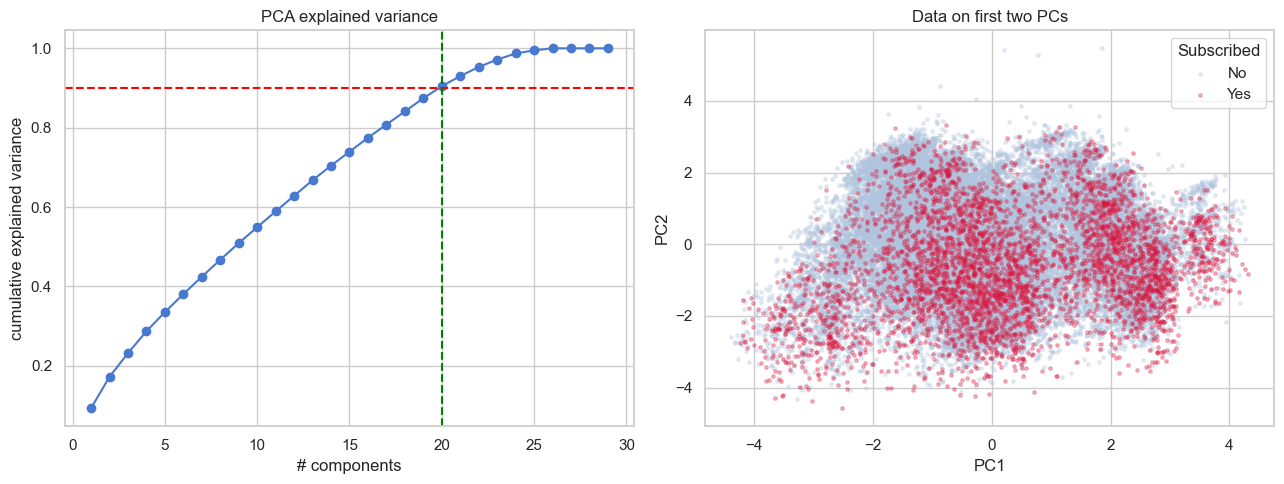

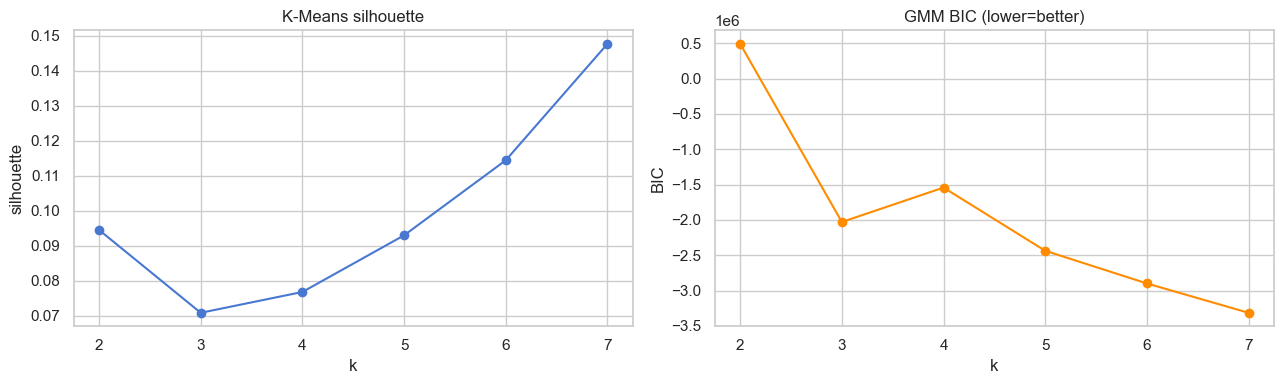

Best k (K-Means silhouette) = 7, silhouette = 0.148
y            0     1  subscribe_rate
cluster                             
0         3050   298           0.089
1        12085  1501           0.110
2          539   219           0.289
3         7531   598           0.074
4         6470  1041           0.139
5          866   158           0.154
6         1396   416           0.230
Overall rate = 0.117 | Adjusted Rand Index = 0.0107


(PCA(), 7)

In [ ]:
def phase1_unsupervised():
    X_train, _, y_train, _ = split_and_scale(preprocess_data(load_data()), scale=True)
    pca, n_comp = pca_analysis(X_train, y_train)
    best_k, ct = cluster_analysis(X_train, y_train)
    return pca, best_k


phase1_unsupervised()


### Phase I — Takeaway

**PCA.** 20 of 29 components are needed to reach 90% of the variance, and the first two PCs
capture only 17.2% — the data has no compact low-dimensional structure. Most of the dimensionality
comes from the one-hot categoricals (`job`, `poutcome`, `contact`, …), which are near-orthogonal
and so resist compression. The 2D projection is therefore only a rough view.

**Clustering.** The best K-Means solution (k = 7) has a silhouette of just 0.148, and GMM/BIC agrees
the structure is weak: customers form overlapping, loosely-defined clusters rather than crisp segments.

**Alignment with the target.** The Adjusted Rand Index is 0.011 — essentially zero — so the clusters
do **not** reconstruct the yes/no labelling. But the per-cluster subscription rates are not flat:
cluster 2 converts at **28.9%** and cluster 6 at **23.0%**, roughly 2–2.5× the 11.7% base rate, while
cluster 3 sits at **7.4%**. So the unsupervised structure is *mildly informative* — a couple of segments
are clearly more receptive — yet no single cluster is majority-subscriber, which is why ARI stays near zero.

**Conclusion.** There is some exploitable structure for targeting and EDA, but clustering alone cannot
separate subscribers. Prediction needs supervised models — consistent with the rest of the project.


## Phase II — Linear and Regularized Models
Baseline + logistic regression with a Ridge/Lasso (λ) sweep, examining how regularization shifts the coefficients.


In [18]:
def cv_classification_metrics(model, X, y, cv):
    scoring = {
        'accuracy': 'accuracy',
        'f1':       'f1',
        'roc_auc':  'roc_auc',
        'aupr':     'average_precision',
    }
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    return {
        'Accuracy': scores['test_accuracy'].mean(),
        'F1':       scores['test_f1'].mean(),
        'ROC-AUC':  scores['test_roc_auc'].mean(),
        'AUPR':     scores['test_aupr'].mean(),
        'Fit Time (s)': scores['fit_time'].mean(),
        '_auc_folds': scores['test_roc_auc'],
    }

In [19]:
# Baseline model which always predicts the majority class. All models should outperform this to be considered useful.
def baseline_model(X_train, y_train, cv):    
    dummy = DummyClassifier(strategy='most_frequent', random_state=42)
    dummy_metrics = cv_classification_metrics(dummy, X_train, y_train, cv)
    for k, v in dummy_metrics.items():
        if not k.startswith('_'):
            print(f"  {k}: {v:.4f}")

    return dummy_metrics

In [20]:
# Logistic regression unregularized 
def logistic_regression_unregularized_model(X_train, y_train, cv):
    lr = LogisticRegression(C=1e6, solver='saga', max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_metrics = cv_classification_metrics(lr, X_train, y_train, cv)
    
    print(f"\nLogistic Regression (unregularized)")
    for k, v in lr_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")
            
    return lr, lr_metrics

In [21]:
# Regularization sweep for logistic regression

def regularization_sweep(X_train, y_train, cv):
    lambdas  = [1e-4, 1e-3, 1e-2, 0.1, 0.5, 1, 5, 10, 50, 100]
    C_values = [1/l for l in lambdas]
    
    sweep_results = []
    for C in C_values:
        r = cv_classification_metrics(
            LogisticRegression(C=C, penalty='l2', solver='saga', max_iter=1000, random_state=42),
            X_train, y_train, cv)
        l = cv_classification_metrics(
            LogisticRegression(C=C, penalty='l1', solver='saga', max_iter=1000, random_state=42),
            X_train, y_train, cv)
        sweep_results.append({
            'lambda':         1/C,
            'Ridge Accuracy': r['Accuracy'], 'Ridge F1':   r['F1'],
            'Ridge AUC':      r['ROC-AUC'],  'Ridge AUPR': r['AUPR'],
            'Lasso Accuracy': l['Accuracy'], 'Lasso F1':   l['F1'],
            'Lasso AUC':      l['ROC-AUC'],  'Lasso AUPR': l['AUPR'],
        })
    
    sweep_df = pd.DataFrame(sweep_results).set_index('lambda')
    print("\nRegularization sweep (all CV metrics):")
    print(sweep_df.round(4))
    return sweep_df, C_values

In [22]:
# Visualization of regularization effects

def plot_lamba_sweep(sweep_df, lr_metrics):    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    plot_cols = [
        ('AUC',      'ROC-AUC'),
        ('AUPR',     'AUPR'),
        ('F1',       'F1'),
        ('Accuracy', 'Accuracy'),
    ]
    for ax, (col_suffix, ylabel) in zip(axes.flatten(), plot_cols):
        ax.plot(sweep_df.index, sweep_df[f'Ridge {col_suffix}'], marker='o', label='Ridge (L2)')
        ax.plot(sweep_df.index, sweep_df[f'Lasso {col_suffix}'], marker='s', label='Lasso (L1)')
        metric_key = 'ROC-AUC' if col_suffix == 'AUC' else ylabel
        ax.axhline(lr_metrics[metric_key], linestyle='--', color='gray', label='Unregularized')
        ax.set_xscale('log')
        ax.set_xlabel('lambda (regularization strength)')
        ax.set_ylabel(f'CV {ylabel}')
        ax.set_title(f'Effect of Regularization on {ylabel}')
        ax.legend(fontsize=8)
    plt.suptitle('Regularization Sweep — Ridge vs Lasso', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


In [23]:
# Best models via LogisticRegressionCV, sklearn selects the best C via internal CV 
def best_regularized_models(X_train, y_train, cv, C_values):
    ridge_cv = LogisticRegressionCV(
        Cs=C_values, penalty='l2', solver='saga',
        cv=cv, scoring='roc_auc', max_iter=1000, random_state=42
    )
    ridge_cv.fit(X_train, y_train)
    # Use plain LR at best C to avoid get_params() leaking into metrics
    ridge_best = LogisticRegression(C=ridge_cv.C_[0], penalty='l2', solver='saga',
                                     max_iter=1000, random_state=42)
    ridge_metrics = cv_classification_metrics(ridge_best, X_train, y_train, cv)
    
    print(f"\nBest Ridge  lambda={1/ridge_cv.C_[0]:.4f}")
    for k, v in ridge_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    lasso_cv = LogisticRegressionCV(
        Cs=C_values, penalty='l1', solver='saga',
        cv=cv, scoring='roc_auc', max_iter=1000, random_state=42
    )
    lasso_cv.fit(X_train, y_train)
    lasso_best = LogisticRegression(C=lasso_cv.C_[0], penalty='l1', solver='saga',
                                     max_iter=1000, random_state=42)
    lasso_metrics = cv_classification_metrics(lasso_best, X_train, y_train, cv)
    print(f"\nBest Lasso  lambda={1/lasso_cv.C_[0]:.4f}")
    for k, v in lasso_metrics.items():
        if not k.startswith('_'):
            print(f"  CV {k}: {v:.4f}")

    return ridge_cv, lasso_cv, ridge_metrics, lasso_metrics

## Phase III — Kernel Methods (SVM)
Linear, RBF and polynomial SVMs, tuned with grid search on a stratified subsample for speed.


In [24]:
def svm_default_models(X_train, y_train, cv):
    # DEFAULT MODELS: all three kernels, no tuning
    print("=== SVM Default Models (untuned) ===")
 
    results = {}
    for kernel, kwargs in [('linear', {}), ('rbf', {}), ('poly', {'degree': 3})]:
        svm = SVC(kernel=kernel, class_weight='balanced',
                  probability=True, random_state=42, **kwargs)
        t0 = time()
        svm.fit(X_train, y_train)
        train_time = time() - t0
 
        m = cv_classification_metrics(svm, X_train, y_train, cv)
        m['Train time (s)'] = round(train_time, 2)
        results[f'SVM {kernel} (default)'] = m
        print(f"  {kernel}: AUC={m['ROC-AUC']:.4f}  F1={m['F1']:.4f}  "
              f"Time={timedelta(seconds=train_time)}")
 
    default_df = pd.DataFrame({
        name: {k: v for k, v in m.items() if not k.startswith('_')}
        for name, m in results.items()
    }).T
    print("\nDefault SVM comparison:")
    print(default_df.round(4))


In [25]:
# GRID SEARCH TUNING
# Runs on a 30% stratified subsample for speed, then best params are refitted on the full training set in svm_best_models()
def svm_grid_search(X_train, y_train, cv):
    print("\n=== SVM Grid Search ===")
 
    # 30% subsample — preserves class balance via stratify
    X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=0.3,
                              stratify=y_train, random_state=42)
    print(f"Subsampling to {X_sub.shape[0]} samples (30%) for speed")
 
    base_kwargs = dict(class_weight='balanced', probability=True, random_state=42)
    scoring     = dict(accuracy='accuracy', f1='f1',
                       roc_auc='roc_auc', aupr='average_precision')
 
    # Linear
    t0 = time()
    gs_linear = GridSearchCV(
        SVC(kernel='linear', **base_kwargs),
        param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1, 5, 10]},
        scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1
    ).fit(X_sub, y_sub)
    print(f"\nLinear — {timedelta(seconds=time()-t0)}  "
          f"best: {gs_linear.best_params_}  AUC: {gs_linear.best_score_:.4f}")
 
    # RBF
    t0 = time()
    gs_rbf = GridSearchCV(
        SVC(kernel='rbf', **base_kwargs),
        param_grid={'C':     [0.1, 1, 5, 10, 50],
                    'gamma': ['scale', 'auto', 0.01, 0.001]},
        scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1
    ).fit(X_sub, y_sub)
    print(f"RBF    — {timedelta(seconds=time()-t0)}  "
          f"best: {gs_rbf.best_params_}  AUC: {gs_rbf.best_score_:.4f}")
 
    # Polynomial
    t0 = time()
    gs_poly = GridSearchCV(
        SVC(kernel='poly', **base_kwargs),
        param_grid={'C':      [0.1, 1, 5, 10],
                    'degree': [2, 3, 5]},
        scoring=scoring, refit='roc_auc', cv=cv, n_jobs=-1
    ).fit(X_sub, y_sub)
    print(f"Poly   — {timedelta(seconds=time()-t0)}  "
          f"best: {gs_poly.best_params_}  AUC: {gs_poly.best_score_:.4f}")
 
    return gs_linear, gs_rbf, gs_poly


In [26]:
# 3. REFIT BEST PARAMS ON FULL TRAINING SET + COLLECT PROPER METRICS
def svm_best_models(gs_linear, gs_rbf, gs_poly, X_train, y_train, cv):
    print("\n=== SVM Best Models (full training set) ===")
 
    base_kwargs = dict(class_weight='balanced', probability=True, random_state=42)
    models, metrics_out = {}, {}
 
    configs = [
        ('SVM Linear', 'linear', gs_linear.best_params_),
        ('SVM RBF',    'rbf',    gs_rbf.best_params_),
        ('SVM Poly',   'poly',   gs_poly.best_params_),
    ]
 
    for name, kernel, params in configs:
        svm = SVC(kernel=kernel, **base_kwargs, **params)
        t0 = time()
        svm.fit(X_train, y_train)
        train_time = time() - t0
 
        m = cv_classification_metrics(svm, X_train, y_train, cv)
        m['Train time (s)'] = round(train_time, 2)
 
        models[name]     = svm
        metrics_out[name] = m
 
        print(f"\n{name}  params={params}")
        for k, v in m.items():
            if not k.startswith('_'):
                print(f"  CV {k}: {v:.4f}" if k != 'Train time (s)'
                      else f"  Train time: {timedelta(seconds=v)}")
 
    return (models['SVM Linear'], models['SVM RBF'],  models['SVM Poly'],
            metrics_out['SVM Linear'], metrics_out['SVM RBF'], metrics_out['SVM Poly'])

In [27]:
# VISUALISATION: kernel comparison across all metrics + train time
def plot_svm_comparison(m_linear, m_rbf, m_poly):
    metric_keys = ['Accuracy', 'F1', 'ROC-AUC', 'AUPR']
    kernels     = ['Linear', 'RBF', 'Polynomial']
    values      = [[m_linear[k], m_rbf[k], m_poly[k]] for k in metric_keys]
 
    x     = np.arange(len(kernels))
    width = 0.18
 
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, (metric, vals) in enumerate(zip(metric_keys, values)):
        ax.bar(x + i * width, vals, width, label=metric)
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(kernels)
    ax.set_ylabel('CV Score')
    ax.set_ylim(0, 1)
    ax.set_title('SVM Kernel Comparison — All CV Metrics')
    ax.legend()
    plt.tight_layout()
    plt.show()
 
    # Training time
    times = [m_linear['Train time (s)'], m_rbf['Train time (s)'], m_poly['Train time (s)']]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(kernels, times, color=['steelblue', 'coral', 'mediumseagreen'])
    ax.set_ylabel('Training time (seconds)')
    ax.set_title('SVM Training Time by Kernel')
    plt.tight_layout()
    plt.show()


## Phase IV — Ensemble Methods
Random Forest (bagging) and Gradient Boosting (boosting); compare metrics, training time and feature importance.


In [28]:

# --- PHASE IV: ENSEMBLE METHODS ---
# --- PHASE IV: ENSEMBLE METHODS (UPGRADED) ---
def train_ensemble_models(X_train, y_train, cv):
    print("\nTraining and Tuning Random Forest...")
    # 1. Define the parameter grid
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [10, 15, None],
        'min_samples_split': [5, 10]
    }
    # 2. Search for the best combination (n_iter=4 keeps it relatively fast)
    rf_search = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, class_weight='balanced'), 
        rf_params, n_iter=4, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    rf_search.fit(X_train, y_train)
    rf_best = rf_search.best_estimator_
    print(f"  Best RF Params: {rf_search.best_params_}")
    
    # 3. Get metrics for the best model
    rf_metrics = cv_classification_metrics(rf_best, X_train, y_train, cv)
    for k, v in rf_metrics.items():
        if not k.startswith('_'): print(f"  CV {k}: {v:.4f}")

    print("\nTraining and Tuning Gradient Boosting...")
    gb_params = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 4, 5]
    }
    gb_search = RandomizedSearchCV(
        GradientBoostingClassifier(random_state=42), 
        gb_params, n_iter=4, cv=cv, scoring='roc_auc', n_jobs=-1, random_state=42
    )
    gb_search.fit(X_train, y_train)
    gb_best = gb_search.best_estimator_
    print(f"  Best GB Params: {gb_search.best_params_}")
    
    gb_metrics = cv_classification_metrics(gb_best, X_train, y_train, cv)
    for k, v in gb_metrics.items():
        if not k.startswith('_'): print(f"  CV {k}: {v:.4f}")

    return rf_best, gb_best, rf_metrics, gb_metrics

def plot_ensemble_feature_importance(rf, gb, X_train):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Random Forest Importance
    rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    rf_importances.sort_values().plot(kind='barh', ax=ax1, color='#2ecc71')
    ax1.set_title('Top 15 Features - Random Forest')
    ax1.set_xlabel('Gini Importance')
    
    # Gradient Boosting Importance
    gb_importances = pd.Series(gb.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
    gb_importances.sort_values().plot(kind='barh', ax=ax2, color='#e74c3c')
    ax2.set_title('Top 15 Features - Gradient Boosting')
    ax2.set_xlabel('Friedman MSE Importance')
    
    plt.tight_layout()
    plt.show()

In [29]:
# Coefficient comparison for unregularized vs best Ridge vs best Lasso
def plot_coefficients(lr, ridge_cv, lasso_cv, X_train):
    coef_df = pd.DataFrame({
        'Unregularized': lr.coef_[0],
        'Ridge':         ridge_cv.coef_[0],
        'Lasso':         lasso_cv.coef_[0],
    }, index=X_train.columns)
    
    n_zeroed = (coef_df['Lasso'] == 0).sum()
    print(f"\nLasso zeroed {n_zeroed}/{len(X_train.columns)} features")
    
    # Top 15 features by Ridge magnitude
    top_features = coef_df['Ridge'].abs().nlargest(15).index
    fig, ax = plt.subplots(figsize=(10, 6))
    coef_df.loc[top_features].plot(kind='barh', ax=ax)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title('Top 15 Feature Coefficients — Unregularized vs Ridge vs Lasso')
    ax.set_xlabel('Coefficient value')
    plt.tight_layout()
    plt.show()
    
    fig, axes = plt.subplots(3, 1, figsize=(20, 4))
    for ax, col in zip(axes, coef_df.columns):
        sns.heatmap(coef_df[[col]].T, annot=False, cmap='coolwarm', center=0,
                    linewidths=0.3, ax=ax, cbar=True)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

### k-Nearest Neighbours & Neural Network (MLP)
Two further models for the comparison: a tuned distance-weighted k-NN (instance-based) and an MLP neural network with early stopping.


In [30]:
def train_knn_and_mlp(X_train, y_train, cv):
    # k-NN -- instance-based; tune neighbourhood size and weighting
    print("\nTuning k-NN...")
    knn_search = GridSearchCV(
        KNeighborsClassifier(),
        {"n_neighbors": [15, 25, 51, 75], "weights": ["uniform", "distance"]},
        cv=cv, scoring="roc_auc", n_jobs=-1,
    ).fit(X_train, y_train)
    knn = knn_search.best_estimator_
    print(f"  Best k-NN params: {knn_search.best_params_}")
    knn_metrics = cv_classification_metrics(knn, X_train, y_train, cv)
    for k, v in knn_metrics.items():
        if not k.startswith("_"): print(f"  CV {k}: {v:.4f}")

    # Neural network (MLP) -- early stopping guards against overfitting
    print("\nTuning Neural Network (MLP)...")
    mlp_search = GridSearchCV(
        MLPClassifier(max_iter=300, early_stopping=True, random_state=42),
        {"hidden_layer_sizes": [(64,), (64, 32)], "alpha": [1e-4, 1e-3]},
        cv=cv, scoring="roc_auc", n_jobs=-1,
    ).fit(X_train, y_train)
    mlp = mlp_search.best_estimator_
    print(f"  Best MLP params: {mlp_search.best_params_}")
    mlp_metrics = cv_classification_metrics(mlp, X_train, y_train, cv)
    for k, v in mlp_metrics.items():
        if not k.startswith("_"): print(f"  CV {k}: {v:.4f}")

    return knn, mlp, knn_metrics, mlp_metrics


### Class Imbalance — Over / Under-sampling
Compare no sampling, `class_weight`, SMOTE (oversampling) and random undersampling — each fit *inside* the CV folds to avoid leakage — on a linear (LR) and a tree (RF) model.


In [31]:
def compare_sampling_strategies(X_train, y_train, cv):
    """Compare imbalance strategies on a linear (LR) and a tree (RF) model.
    Samplers are wrapped in an imblearn Pipeline so they are fit ONLY on the training
    portion of each CV fold -- never on the validation fold (prevents leakage)."""
    estimators = {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    }
    strategies = ["None", "class_weight", "SMOTE (over)", "Undersample"]
    samplers = {"SMOTE (over)": SMOTE(random_state=42),
                "Undersample":  RandomUnderSampler(random_state=42)}

    rows = []
    for est_name, base in estimators.items():
        for strat in strategies:
            if strat == "class_weight":
                model = clone(base).set_params(class_weight="balanced")
            elif strat == "None":
                model = clone(base)
            else:
                model = ImbPipeline([("sampler", samplers[strat]), ("clf", clone(base))])
            m = cv_classification_metrics(model, X_train, y_train, cv)
            rows.append({"Model": est_name, "Strategy": strat,
                         "F1": m["F1"], "ROC-AUC": m["ROC-AUC"], "AUPR": m["AUPR"]})
            print(f"  {est_name:20} {strat:14} F1={m['F1']:.3f}  AUC={m['ROC-AUC']:.3f}  AUPR={m['AUPR']:.3f}")

    results = pd.DataFrame(rows)

    # F1 is the imbalance-sensitive metric; AUC/AUPR are threshold-independent
    pivot = results.pivot(index="Strategy", columns="Model", values="F1").loc[strategies]
    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_ylabel("CV F1"); ax.set_title("Effect of imbalance strategy on F1")
    ax.set_xticklabels(strategies, rotation=0); ax.legend(title="Model")
    plt.tight_layout(); plt.show()
    return results


Dataset loaded: 45211 rows, 17 columns.
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
  Logistic Regression  None           F1=0.374  AUC=0.881  AUPR=0.514
  Logistic Regression  class_weight   F1=0.480  AUC=0.882  AUPR=0.509
  Logistic Regression  SMOTE (over)   F1=0.483  AUC=0.881  AUPR=0.506
  Logistic Regression  Undersample    F1=0.478  AUC=0.881  AUPR=0.508
  Random Forest        None           F1=0.456  AUC=0.916  AUPR=0.569
  Random Forest        class_weight   F1=0.423  AUC=0.917  AUPR=0.571
  Random Forest        SMOTE (over)   F1=0.543  AUC=0.914  AUPR=0.539
  Random Forest        Undersample    F1=0.539  AUC=0.915  AUPR=0.544


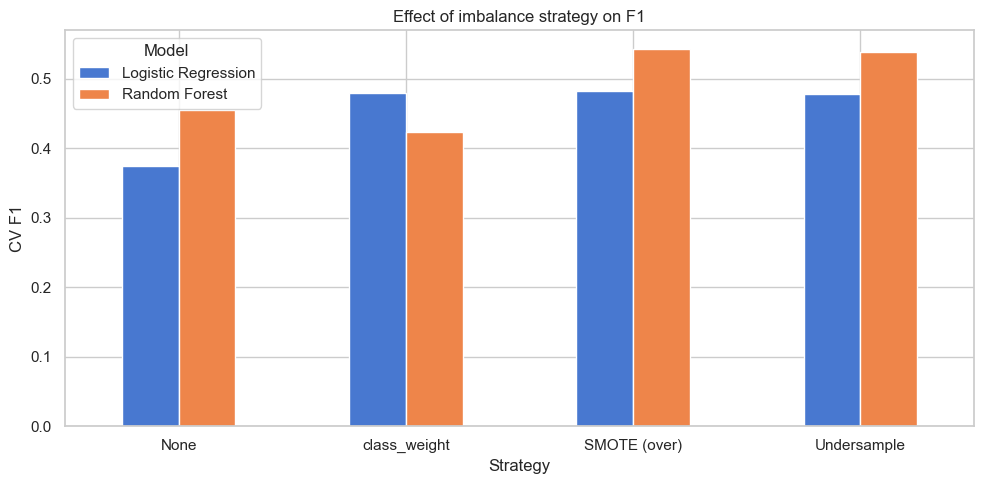

,Model,Strategy,F1,ROC-AUC,AUPR
0,Logistic Regression,None,0.373987,0.880987,0.513741
1,Logistic Regression,class_weight,0.479855,0.881616,0.509247
2,Logistic Regression,SMOTE (over),0.482873,0.880666,0.505867
3,Logistic Regression,Undersample,0.477672,0.881290,0.507756
4,Random Forest,None,0.455593,0.915997,0.569171
5,Random Forest,class_weight,0.422896,0.917208,0.570697
6,Random Forest,SMOTE (over),0.542589,0.914085,0.538710
7,Random Forest,Undersample,0.538833,0.915248,0.543522


In [32]:
def sampling_experiment():
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    X_train, _, y_train, _ = split_and_scale(preprocess_data(load_data()))
    return compare_sampling_strategies(X_train, y_train, cv)


sampling_experiment()


## Phase V — Model Selection and Validation
Rank all models by cross-validated metrics, test the top gap with a paired t-test, and evaluate the winner on the held-out test set.


In [33]:
# Model comparison -- expects metrics: {name: metrics_dict}
def model_comparison(metrics):
    comparison_df = pd.DataFrame({
        name: {k: v for k, v in m.items() if not k.startswith('_')}
        for name, m in metrics.items()
    }).T

    print("\n--- Model Comparison (CV metrics & Training Time) ---")
    print(comparison_df.round(4))

    best_name = comparison_df['ROC-AUC'].idxmax()
    print(f"\nSelected model (highest CV AUC): {best_name}")
    return comparison_df['ROC-AUC'].sort_values(ascending=False)


In [34]:
# Paired t-test on AUC folds between best and runner-up: is the gap real or just split noise?
def paired_t_test_on_auc(metrics, sorted_models):
    best_name = sorted_models.index[0]
    runner_up = sorted_models.index[1]

    best_folds   = metrics[best_name]['_auc_folds']
    runner_folds = metrics[runner_up]['_auc_folds']

    t_stat, p_val = stats.ttest_rel(best_folds, runner_folds)
    print(f"\nPaired t-test: {best_name} vs {runner_up}")
    print(f"  t={t_stat:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print("  Difference is statistically significant (p < 0.05)")
    else:
        print("  No significant difference (p >= 0.05) -- models are comparable")


In [35]:
# Final test-set evaluation of the selected model -- expects models: {name: fitted_estimator}
def final_evaluation(best_name, models, X_test, y_test):
    best_model = models[best_name]

    y_pred       = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]

    print(f"\n--- Test Set Results ({best_name}) ---")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  F1:       {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC:  {roc_auc_score(y_test, y_pred_proba):.4f}")
    print(f"  AUPR:     {average_precision_score(y_test, y_pred_proba):.4f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No', 'Yes'])}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=ax1, name=best_name)
    ax1.plot([0, 1], [0, 1], 'k--', label='Random baseline')
    ax1.set_title('ROC Curve (Test Set)'); ax1.legend()
    PrecisionRecallDisplay.from_estimator(best_model, X_test, y_test, ax=ax2, name=best_name)
    ax2.set_title('Precision-Recall Curve / AUPR (Test Set)')
    plt.suptitle(f'Final Evaluation -- {best_name}', fontsize=13)
    plt.tight_layout(); plt.show()


In [36]:
# Stratified CV preserves the ~88/12 class balance in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def complete_pipeline():
    train_df = load_data(test=False)

    # Phases I, II, III — log transformed and scaled
    clean_df = preprocess_data(train_df, log_transform=True)
    X_train, X_test, y_train, y_test = split_and_scale(clean_df, scale=True)

    # Phase IV — no log transform, no scaling (tree-based models)
    clean_df_trees = preprocess_data(train_df, log_transform=False)
    X_train_trees, _, y_train_trees, _ = split_and_scale(clean_df_trees, scale=False)

    models, metrics = {}, {}

    # Phase II -- Linear models
    dummy = DummyClassifier(strategy='most_frequent', random_state=42).fit(X_train, y_train)
    models['Baseline'], metrics['Baseline'] = dummy, baseline_model(X_train, y_train, cv)

    lr, lr_metrics = logistic_regression_unregularized_model(X_train, y_train, cv)
    models['LR (unreg)'], metrics['LR (unreg)'] = lr, lr_metrics

    sweep_df, C_values = regularization_sweep(X_train, y_train, cv)
    plot_lamba_sweep(sweep_df, lr_metrics)
    ridge_cv, lasso_cv, ridge_metrics, lasso_metrics = best_regularized_models(X_train, y_train, cv, C_values)
    plot_coefficients(lr, ridge_cv, lasso_cv, X_train)
    models['Ridge'], metrics['Ridge'] = ridge_cv, ridge_metrics
    models['Lasso'], metrics['Lasso'] = lasso_cv, lasso_metrics

    # Phase III -- SVM
    svm_default_models(X_train, y_train, cv)
    gs_linear, gs_rbf, gs_poly = svm_grid_search(X_train, y_train, cv)
    svm = svm_best_models(gs_linear, gs_rbf, gs_poly, X_train, y_train, cv)
    svm_linear, svm_rbf, svm_poly, svm_linear_metrics, svm_rbf_metrics, svm_poly_metrics = svm
    plot_svm_comparison(svm_linear_metrics, svm_rbf_metrics, svm_poly_metrics)
    models['SVM Linear'], metrics['SVM Linear'] = svm_linear, svm_linear_metrics
    models['SVM RBF'],    metrics['SVM RBF']    = svm_rbf, svm_rbf_metrics
    models['SVM Poly'],   metrics['SVM Poly']   = svm_poly, svm_poly_metrics

    # Phase IV -- Ensembles (unscaled, untransformed)
    rf, gb, rf_metrics, gb_metrics = train_ensemble_models(X_train_trees, y_train_trees, cv)
    plot_ensemble_feature_importance(rf, gb, X_train_trees)
    models['Rand Forest'], metrics['Rand Forest'] = rf, rf_metrics
    models['Grad Boost'],  metrics['Grad Boost']  = gb, gb_metrics

    # k-NN and Neural Network (scaled, same as II and III)
    knn, mlp, knn_metrics, mlp_metrics = train_knn_and_mlp(X_train, y_train, cv)
    models['k-NN'], metrics['k-NN'] = knn, knn_metrics
    models['Neural Net'], metrics['Neural Net'] = mlp, mlp_metrics

    # Phase V -- Comparison, significance test, final evaluation
    sorted_models = model_comparison(metrics)
    paired_t_test_on_auc(metrics, sorted_models)
    final_evaluation(sorted_models.index[0], models, X_test, y_test)

    return models, metrics, sorted_models

Dataset loaded: 45211 rows, 17 columns.
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
Train: (36168, 29), Test: (9043, 29)
Class balance (train) — 0: 31937, 1: 4231
  Accuracy: 0.8830
  F1: 0.0000
  ROC-AUC: 0.5000
  AUPR: 0.1170
  Fit Time (s): 0.0017

Logistic Regression (unregularized)
  CV Accuracy: 0.8957
  CV F1: 0.3739
  CV ROC-AUC: 0.8810
  CV AUPR: 0.5138
  CV Fit Time (s): 0.0605

Regularization sweep (all CV metrics):
          Ridge Accuracy  Ridge F1  Ridge AUC  Ridge AUPR  Lasso Accuracy  \
lambda                                                                      
0.0001            0.8957    0.3739     0.8810      0.5138          0.8957   
0.0010            0.8957    0.3739     0.8810      0.5138          0.8957   
0.0100            0.8957    0.3739     0.8810      0.5138          0.8957   
0.1000            0.8958    0.3739     0.8810      0.5138          0.8957   
0.5000            0.8958    0.3739     0.8810      0.5137          0.895

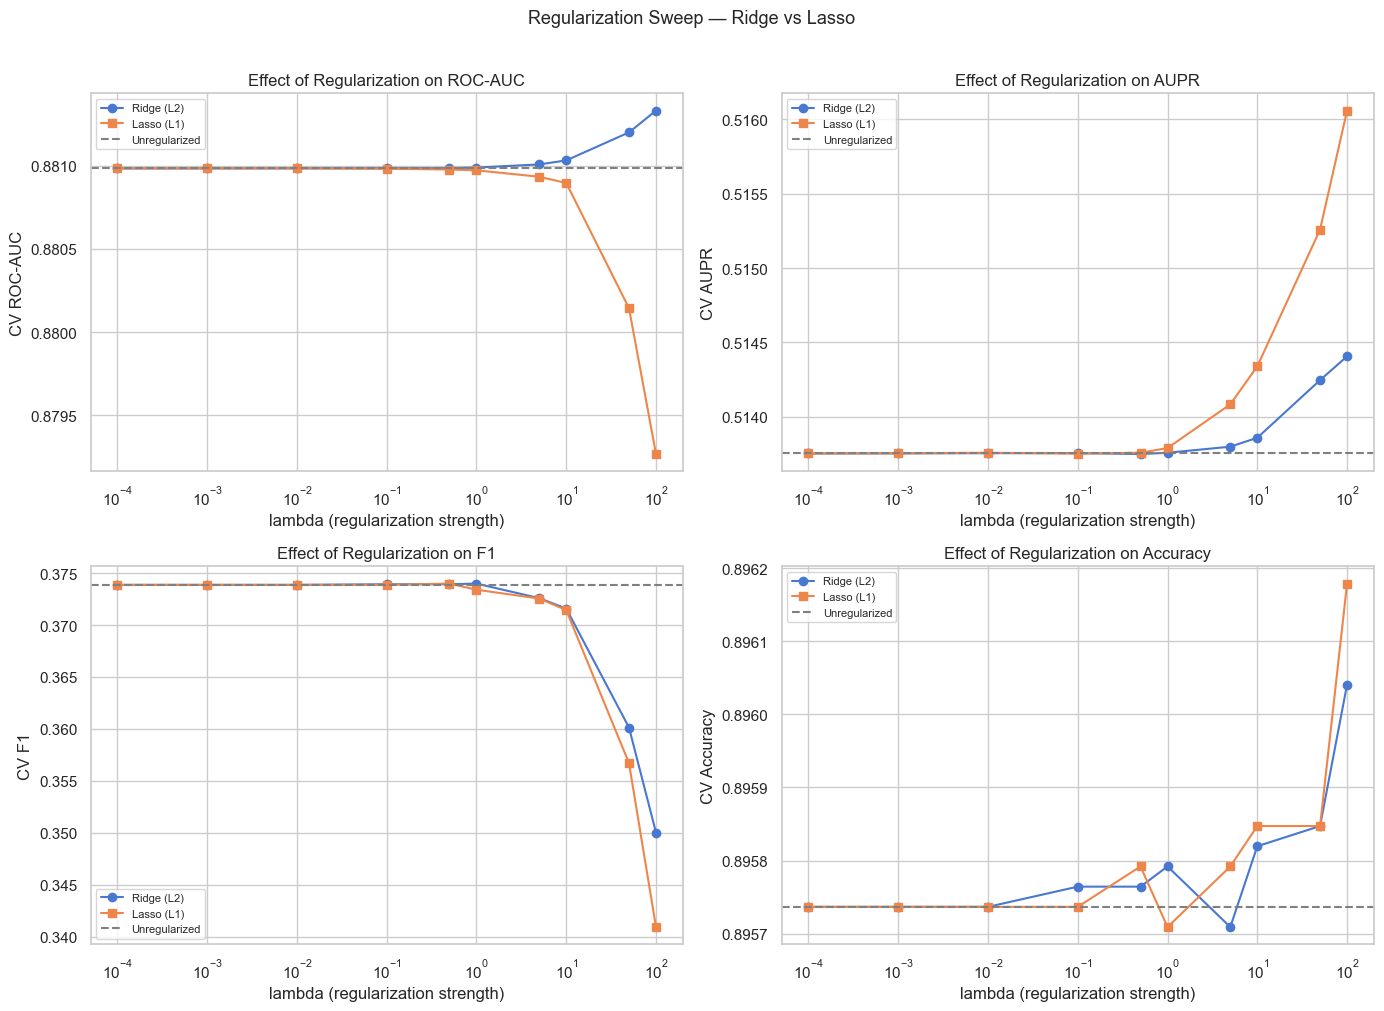


Best Ridge  lambda=100.0000
  CV Accuracy: 0.8960
  CV F1: 0.3500
  CV ROC-AUC: 0.8813
  CV AUPR: 0.5144
  CV Fit Time (s): 0.0502

Best Lasso  lambda=0.0100
  CV Accuracy: 0.8957
  CV F1: 0.3739
  CV ROC-AUC: 0.8810
  CV AUPR: 0.5138
  CV Fit Time (s): 0.0822

Lasso zeroed 3/29 features


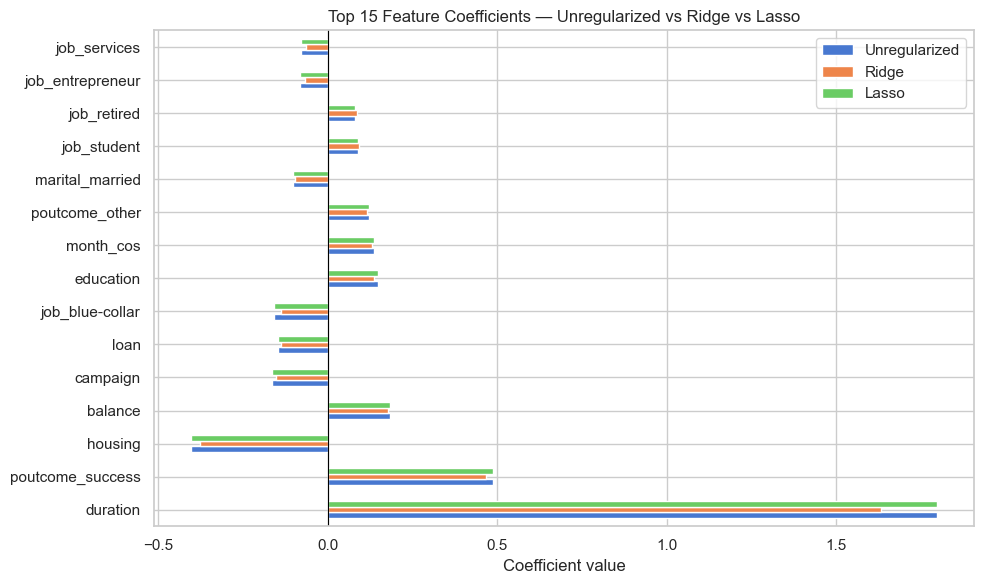

/var/folders/ls/1wdsysgs1v18dvs6sj0dbplh0000gn/T/ipykernel_69723/2559837571.py:27: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


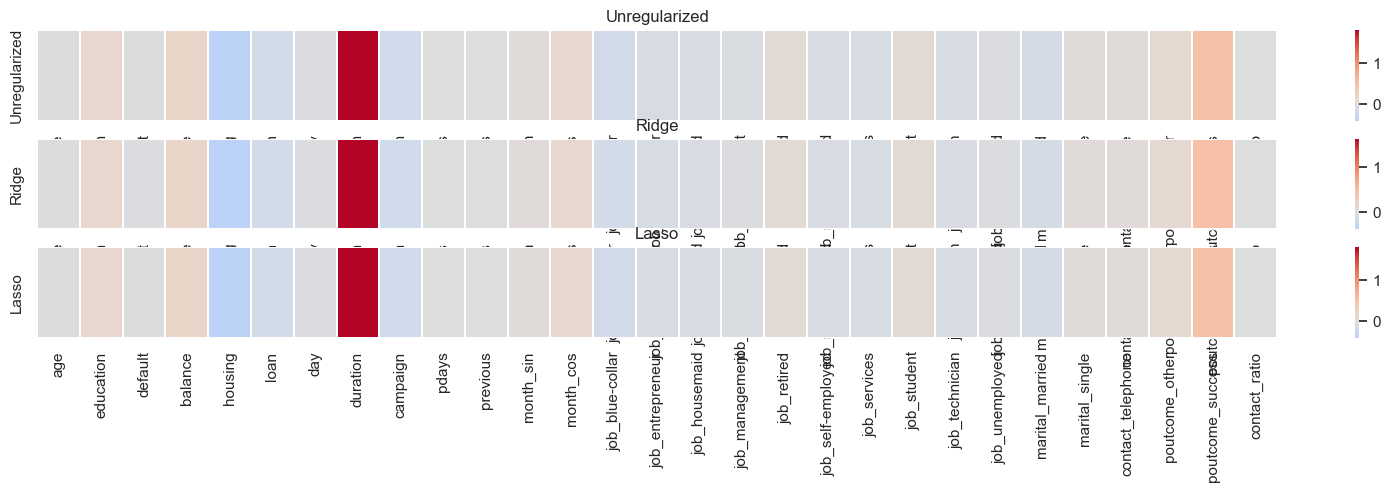

=== SVM Default Models (untuned) ===


In [ ]:
complete_pipeline()